In this notebook, we will demonstrate different problem. 
With supervised learning, our approach was to predict which customer will churn, and with that, to find early indicators to identify potential threats. 
This will be about unsupervised learning. Now we want to group (cluster) customers based on their behaviour, and according to the cluster, to treat them appropriately. 

From this point, there are two ways of working:
1) Use whole dataset, identify all possible clusters, and find out which ones are the most likely to churn
2) Find clusters only among the churn ones. 

Both ways will give us separate insights.

First, I would like to focus on the whole dataset. This will give us broader picture, and when a new customer comes into play, we can categorize him from the start.



In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv('../data/processed/telecom_churn_cleaned.csv')
print(f"Shape: {df.shape}")
df.head(3)

Shape: (7043, 21)


,number of dependents,number of referrals,tenure in months,phone service,avg monthly long distance charges,multiple lines,internet service,internet type,avg monthly gb download,online security,...,device protection plan,premium tech support,unlimited data,contract,paperless billing,payment method,monthly charge,total revenue,churned,age_group
0,0,2,9,1,42.39,0,1,Cable,16.0,0,...,0,1,1,One Year,1,Credit Card,65.6,974.81,0,35-44
1,0,0,9,1,10.69,1,1,Cable,10.0,0,...,0,0,0,Month-to-Month,0,Credit Card,-4.0,610.28,0,45-54
2,0,0,4,1,33.65,0,1,Fiber Optic,30.0,0,...,1,0,1,Month-to-Month,1,Bank Withdrawal,73.9,415.45,1,45-54


In [3]:
df.columns

Index(['number of dependents', 'number of referrals', 'tenure in months',
       'phone service', 'avg monthly long distance charges', 'multiple lines',
       'internet service', 'internet type', 'avg monthly gb download',
       'online security', 'online backup', 'device protection plan',
       'premium tech support', 'unlimited data', 'contract',
       'paperless billing', 'payment method', 'monthly charge',
       'total revenue', 'churned', 'age_group'],
      dtype='object')

For the start, we will prepare data the same way as in supervised learning. 

In [4]:
TARGET = "churned"

X = df.drop(columns=[TARGET, "total revenue"])  # total revenue is highly correlated with tenure in months, so we drop it to avoid data leakage

binary_features = [
    "phone service", "multiple lines", "internet service",
    "online security", "online backup", "device protection plan",
    "premium tech support", "unlimited data", "paperless billing"
]

numeric_features = [c for c in X.select_dtypes(include=["int64", "float64"]).columns 
                    if c not in binary_features]
categorical_features = list(X.select_dtypes(include=["object", "category"]).columns)

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")  


Numeric features: ['number of dependents', 'number of referrals', 'tenure in months', 'avg monthly long distance charges', 'avg monthly gb download', 'monthly charge']
Categorical features: ['internet type', 'contract', 'payment method', 'age_group']


In [5]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("bin", "passthrough", binary_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
])

X_scaled = preprocessor.fit_transform(X)

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# function to plot clusters in 3D using PCA

def plot_clusters_3d(X_scaled, labels, title):
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_scaled)
    
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(
        X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
        c=labels, cmap='viridis', edgecolor='k', s=50, alpha=0.6
    )
    
    plt.colorbar(scatter, ax=ax, label='Cluster', pad=0.1)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


Before actually performing KMeans clustering, I want to find out the optimal number of clusters in this case.

## Determing the right number of clusters

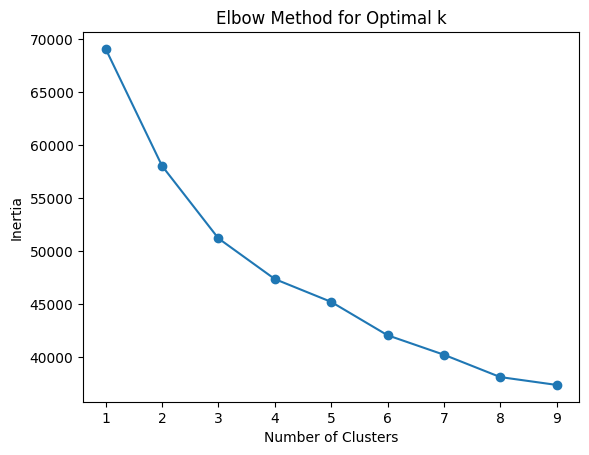

In [7]:
# ## Evaluating Clustering - Elbow Method for K-Means
inertia = []
k_values = range(1, 10)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

This result is a bit tricky. Drop from 2->3 is significant, but only after 4 the curve starts to flatten noticeably. At this point it's debatable whether the right choise here is 3 or 4.
Objectivelly and logically speaking, 4 cluster would provide higher granularity and is more interpretable business-wise. But let's look at the silhuette score and see what we can derive from it, before jumping to conclusions.

In [ ]:
# ## Evaluating Clustering - Silhouette Score for Different k
silhouette_scores = {}
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores[k] = silhouette_score(X_scaled, labels)

plt.figure()
for k, score in silhouette_scores.items():
    plt.annotate(f"{score:.4f}", (k, score), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)

plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k')
plt.show()

Statistically speaking, K=2 has highest silhouette score, but from business standpoint, it's not a good choice. Between K=3 and K=4, the difference is insignificant and there is no 'penalty' for choosing one over the other.
In this case, for previously mentioned reasons, K=4 will be the number we will work with.

## Performing a K-Means clustering

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

### Visualization

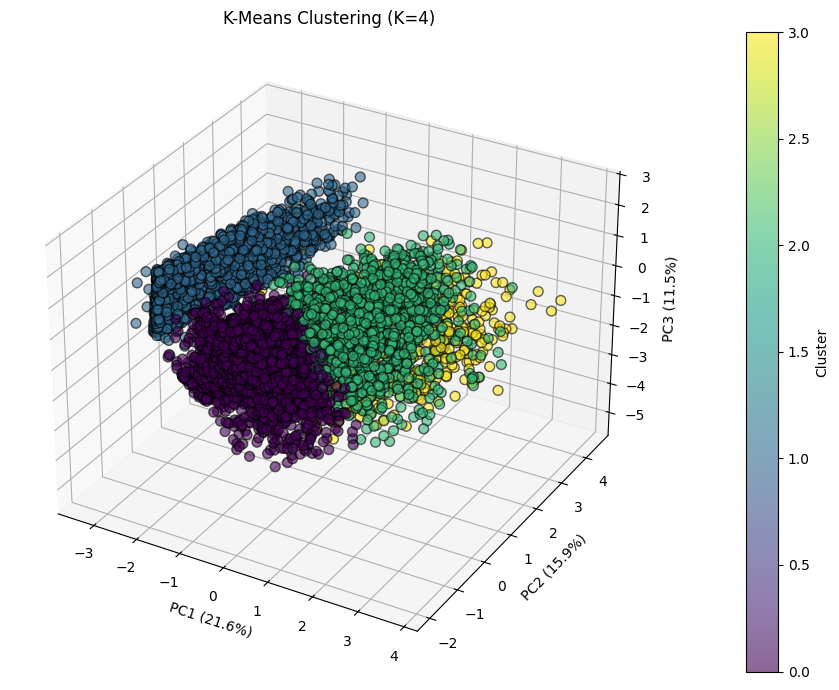

In [ ]:
plot_clusters_3d(X_scaled, df["cluster"], "K-Means Clustering (K=4)")

The 3D PCA plot shows that the dark blue cluster (Cluster 1) is the most clearly 
separated from the rest. The remaining three clusters overlap considerably, 
meaning their differences are more subtle and driven by features that PCA 
compresses away, such as contract type and tenure.

In [ ]:
# Final model quality metrics
silhouette_final = silhouette_score(X_scaled, df["cluster"])

print(f"Final K=4 Model Quality Metrics")
print(f"{'='*35}")
print(f"Silhouette Score: {silhouette_final:.4f}")

Final K=4 Model Quality Metrics
Silhouette Score: 0.1570


### Cluster size

In [ ]:
cluster_sizes = df["cluster"].value_counts().sort_index()
cluster_pct = (cluster_sizes / len(df) * 100).round(1)

print("Cluster Sizes")
print("=" * 35)
for cluster, count, pct in zip(cluster_sizes.index, cluster_sizes.values, cluster_pct.values):
    print(f"Cluster {cluster}: {count:>5} customers ({pct}%)")

Cluster Sizes
Cluster 0:  2775 customers (39.4%)
Cluster 1:  1554 customers (22.1%)
Cluster 2:  2023 customers (28.7%)
Cluster 3:   691 customers (9.8%)


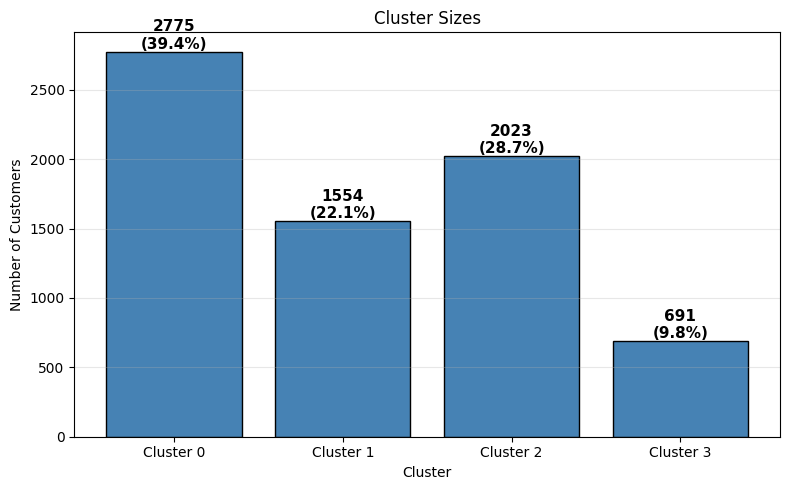

In [ ]:
plt.figure(figsize=(8, 5))
bars = plt.bar(cluster_sizes.index, cluster_sizes.values, color='steelblue', edgecolor='k')

for bar, count, pct in zip(bars, cluster_sizes.values, cluster_pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"{count}\n({pct}%)", ha='center', fontsize=11, fontweight='bold')

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Cluster Sizes")
plt.xticks(cluster_sizes.index, [f"Cluster {i}" for i in cluster_sizes.index])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Cluster profiling

In [ ]:
df.groupby("cluster")[numeric_features].mean().round(2)

,number of dependents,number of referrals,tenure in months,avg monthly long distance charges,avg monthly gb download,monthly charge
cluster,,,,,,
0,0.08,0.53,14.08,21.02,23.54,67.96
1,0.73,2.16,30.69,24.82,0.27,20.17
2,0.12,2.94,56.01,25.07,24.07,88.10
3,2.48,4.27,40.59,20.40,43.48,71.97


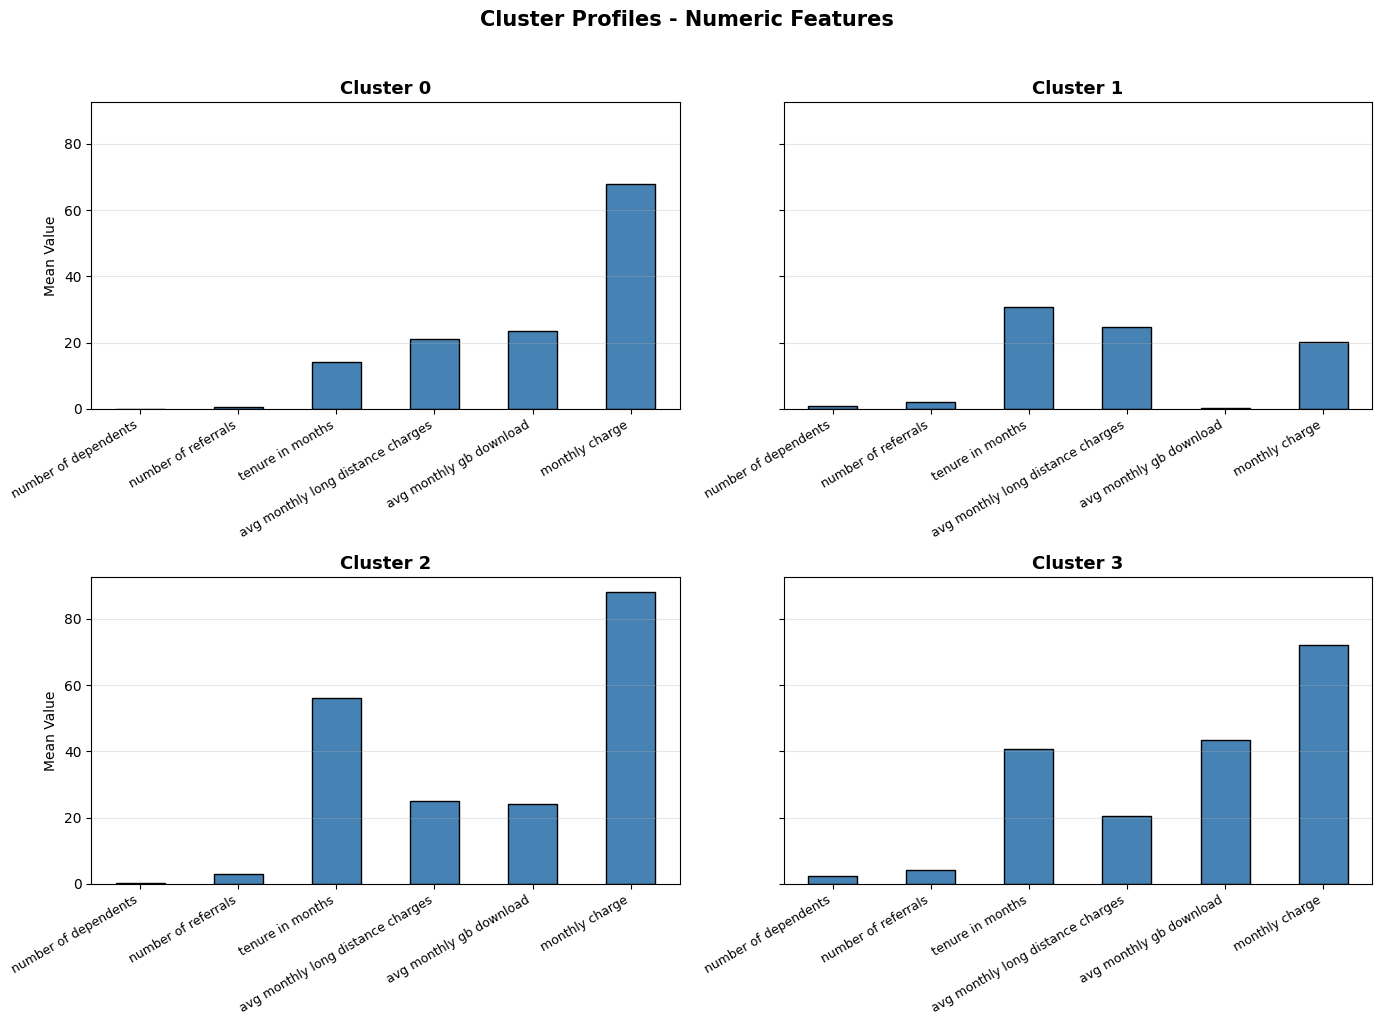

In [ ]:
cluster_profiles = df.groupby("cluster")[numeric_features].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    cluster_profiles.loc[i].plot(kind='bar', ax=ax, color='steelblue', edgecolor='k')
    ax.set_title(f"Cluster {i}", fontsize=13, fontweight='bold')
    ax.set_ylabel("Mean Value")
    ax.set_xticklabels(numeric_features, rotation=30, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Cluster Profiles - Numeric Features", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

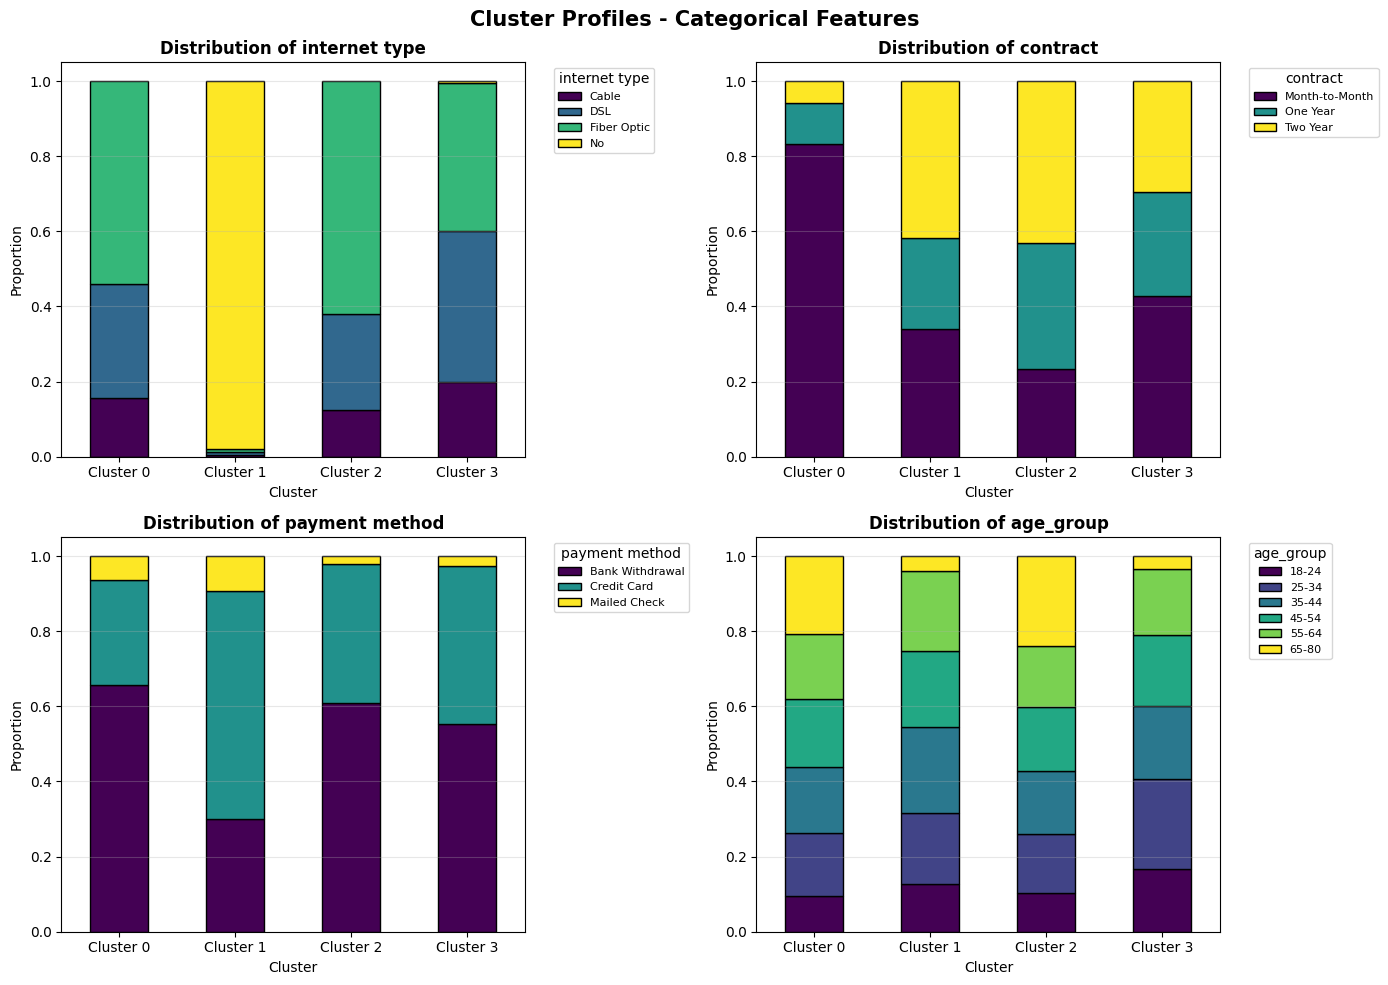

In [ ]:
categorical_features_original = ['internet type', 'contract', 'payment method', 'age_group']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(categorical_features_original):
    ct = df.groupby("cluster")[feat].value_counts(normalize=True).unstack().fillna(0)
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis', edgecolor='k')
    axes[i].set_title(f"Distribution of {feat}", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Proportion")
    axes[i].set_xlabel("Cluster")
    axes[i].set_xticklabels([f"Cluster {i}" for i in range(4)], rotation=0)
    axes[i].legend(title=feat, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle("Cluster Profiles - Categorical Features", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

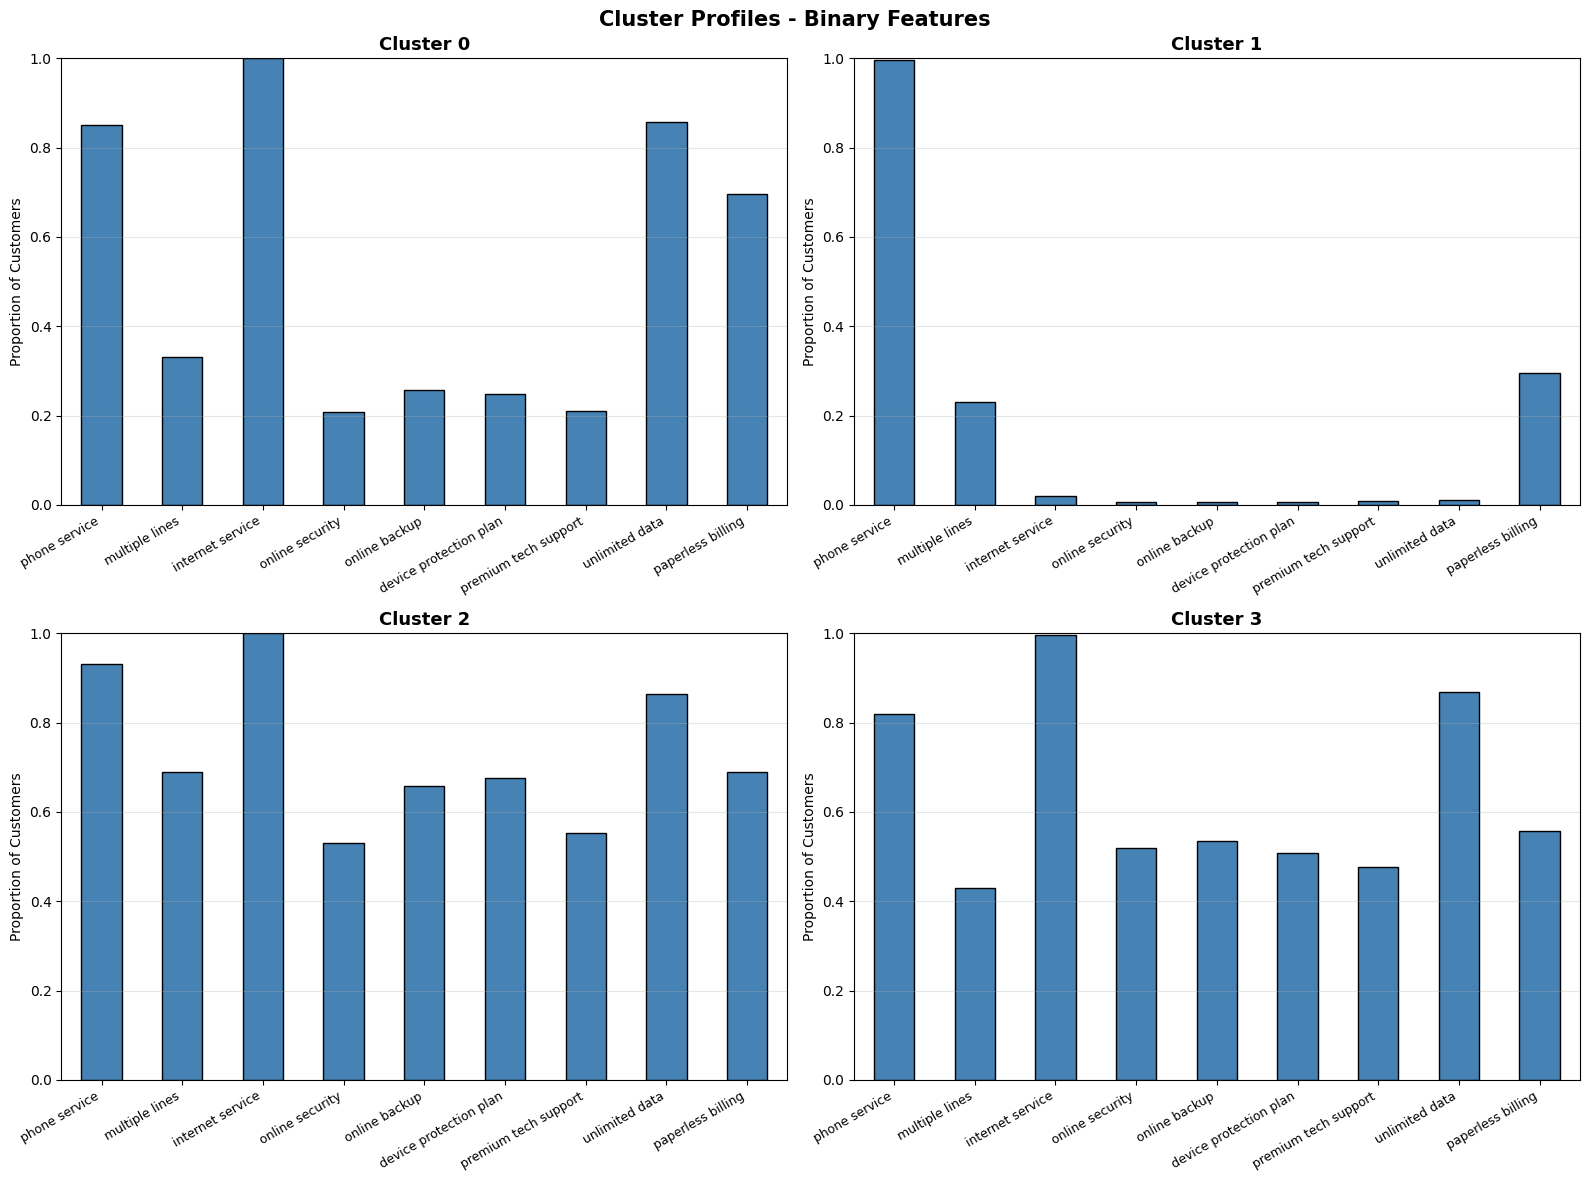

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    cluster_data = df[df["cluster"] == i][binary_features].mean()
    cluster_data.plot(kind='bar', ax=ax, color='steelblue', edgecolor='k')
    ax.set_title(f"Cluster {i}", fontsize=13, fontweight='bold')
    ax.set_ylabel("Proportion of Customers")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(binary_features, rotation=30, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Cluster Profiles - Binary Features", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Profile analysis

### Cluster 0
They really low number of dependents and referrals, which means these are individuals who probably don't have family, and also they are relatively new customers, with an average tenure of 14 months. With long distance charges and amount of GB downloaded they don't differ much from other clusters, but they do have high montly charge, almost as high as cluster 3 with twice as much GB downloaded (on average).
They use mostly Fiber optic and DSL, and their contract is usually month-to-month. This makes sense because they haven't been that long in the company, so they might still don't believe in the company's quality enough to move to longer contract. Payment method is Bank withdrawal, but nowadays this is normal, since many countries in Europe are abandoning cash system. 
All age groups are almost equally present in this group. 
According to binary features, not a large portion of them engage in extras like online backup, online protection, and premium tech support.

These are simple people, probably not married with family and maybe living on a budget. They are here for the internet and unlimited data. They do not have long-term contract, and they have been a consumer the least. I see this cluster as high-risk for churns, since they are still new.

This is the biggest cluster: 40% of customers.



### Cluster 1

What stands out the most about this cluster is that they are the quietest. They most frequently don't have any internet service whatsoever, no extras (backup, protection, premium support), monthly gb download almost nonexistent. They have the lowest monthly charge in amount of 20e. Second lowest monthly charge is cluster 0 with 67e, which is more than 3x as much as this cluster 1. On average, they have been customers for over 2 years, but they don't seem to use everything there is to use. 
All age groups are almost equally present. 
Prefered payment method is Credit Card.

If in an era of Internet this group of people are not using it, they appear a bit stubborn. Maybe they do not want to spend money on anything that is not an absolute necessity, which in this case, is just phone calls and long distance phone calls. 

This cluster is 22% of all customers.
They can be seen visually in PCA graph as dark blue, distinct cluster.

### Cluster 2

This is the cluster that has the most customers with all services included. They spend the most money, and they seem like loyal customers. They have multiple lines, which means that they either have two phones (perhaps one for themselves, and one for work), or a family. Most common type of Internet type is Fiber Optic, which means they care about speed, and may be into streaming options. 
All age groups are present, but we can see that more than 50% is of people with over 35 years, which proves that these are family persons.

They have been customers for about 4 years.
Churn rate should be present, but not the highest.
They make up slightly less than a third of customers - around 30%.

### Cluster 3

Final cluster is probably consisted of people mostly younger than 35, but what they use most of all clusters are gigabytes. They also have multiple lines and they have extras included. They are second group that spends the most.
They have been consumers the longest. They do seem loyal, but there is a possibility they might churn if they find competition with better internet package.

They are also the smallest cluster, of around 10% of customers.


## Churn rate by clusters

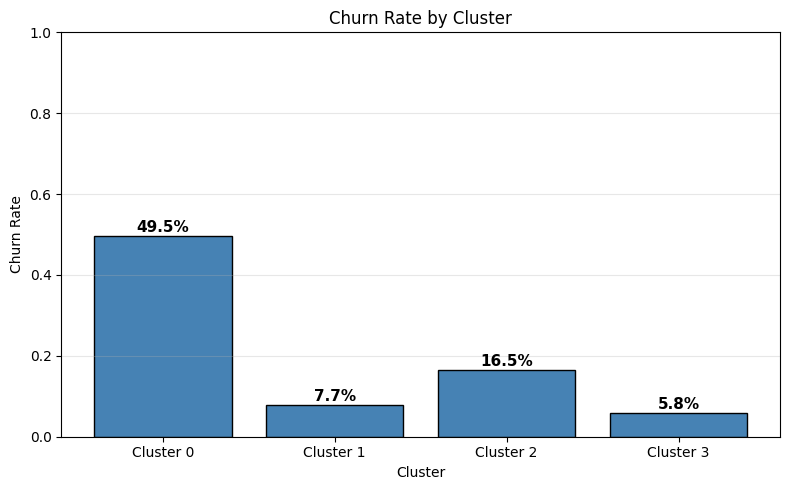

In [ ]:
churn_rate = df.groupby("cluster")["churned"].mean().reset_index()
churn_rate.columns = ["cluster", "churn_rate"]

plt.figure(figsize=(8, 5))
bars = plt.bar(churn_rate["cluster"], churn_rate["churn_rate"], color='steelblue', edgecolor='k')

for bar, rate in zip(bars, churn_rate["churn_rate"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f"{rate:.1%}", ha='center', fontsize=11, fontweight='bold')

plt.xlabel("Cluster")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Cluster")
plt.xticks(churn_rate["cluster"], [f"Cluster {i}" for i in churn_rate["cluster"]])
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

As expected, Cluster 0 has the highest churn rate, while Cluster 3 has the lowest. Cluster 2 seemed loyal in initial look, but since they have second highest churn rate, their high-spend might be part of the problem.

## Business recommedations and next steps

### Cluster 0 - High Priority: Retention Interventions
With a **49.5% churn rate**, this is the most urgent segment to address. These are newer, budget-conscious customers on month-to-month contracts with no strong loyalty anchor yet. Since this is also the largest cluster, they are requiring special attention.

**Recommendations:**
- **Onboarding loyalty program** - Introduce a "first year" incentive program that rewards customers for staying beyond 12 months, such as gradually decreasing monthly charges or bonus data after each quarter.
- **Contract migration incentives** - Offer a meaningful discount (e.g., 15–20% off) to customers who upgrade from month-to-month to a 1-year contract, reducing early churn risk.
- **Unlimited data bundles** - Since they consume data but pay high monthly charges relative to usage, introduce a mid-tier unlimited package that feels like better value.
- **Proactive outreach** - Trigger automated check-ins at months 3, 6, and 12 to assess satisfaction and offer personalized deals before they decide to leave.

---

### Cluster 1 - Low Priority: Passive Retention
At only **7.7% churn**, these customers are stable but underutilizing the product. The risk here is not immediate churn, but long-term stagnation and vulnerability to competitor pricing.

**Recommendations:**
- **Gentle upselling** — Since they've been customers for 2+ years, they have trust built up. Introduce them to internet bundles gradually through targeted campaigns, framing it as "you're already paying; here's what you're missing."
- **Senior/simplicity packages** - If age data supports it, offer a "basic plus" package designed for low-usage customers that includes some internet service at a low price point, easing them into broader adoption.
- **Annual loyalty rewards** - Acknowledge their tenure with small perks (free months, priority support) to maintain goodwill without heavy investment.

---

### Cluster 2 - Medium Priority: Value Protection
A **16.5% churn rate** in the highest-spending segment is a significant revenue risk. Losing even a small number of these customers has a financial impact.

**Recommendations:**
- **Family & multi-line packages** - Since many have multiple lines and are likely households, offer bundled family plans that reduce the per-line cost and increase switching costs (a whole family is harder to move than an individual).
- **Premium loyalty tier** - Create a VIP tier for high-spend customers with perks like free premium tech support, priority network access, or early feature access, making them feel recognized for their spend.
- **Annual contract incentives** - Offer a meaningful price lock for customers who commit to a 2-year plan, protecting revenue and reducing churn likelihood.
- **Regular value reviews** - High spenders are most likely to do competitor comparisons. Proactively offer a "plan review" call every 12 months to ensure they feel they're getting the best deal available internally before they look externally.

---

### Cluster 3 - Low Priority: Competitive Monitoring
At **5.8% churn**, these are your most loyal customers, but their heavy data usage makes them attractive targets for competitors with aggressive internet packages. 
Additionally, this is the smallest cluster.

**Recommendations:**
- **Competitive price matching policy** - For this segment specifically, introduce a retention policy where if a customer presents a competitor offer, the company matches or beats it. The cost of matching is far lower than the cost of losing a long-tenure, high-usage customer.
- **Early access to new products** - These are likely tech-forward, younger users who value being "first." Offering beta features or early 5G/fiber upgrades rewards their loyalty in a non-monetary way.
- **Usage-based rewards** - Since they consume the most data, consider a rewards program tied to usage milestones, reinforcing the relationship the longer they stay.
